In [2]:
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.optimize import minimize

import matplotlib.pyplot as plt

import time

In [3]:
df_k = pd.read_csv('N2.csv')

In [4]:
df_test = pd.read_csv('N2_test.csv')

In [5]:
def mape_loss(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # print(y_true, y_pred)

    errors = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(errors) * 100
    
    return mape

In [6]:
def k_model_poly(T, *coeffs):
    x = T**(-1/3)

    result = 0.0
    for k, coeff in enumerate(coeffs[:]):
        result += coeff * (x ** k)

    return result 
    # return result + coeffs[-1]*(x + 1/x)

# def k_model_poly(T, *coeffs):
#     x = T**(-1/3)
# 
#     n_total = len(coeffs) 
#     
#     n_poly = n_total // 2
#     n_poly2 = n_total - n_poly
#     
#     # n_poly = n_total - 2
# 
#     result = 0.0
# 
#     for k in range(n_poly):
#         result += coeffs[k] * x**k
#     # result = np.exp(result)
#     
#     temp = 0.0
#     for j in range(n_poly2):        
#         temp += coeffs[n_poly + j] * x**j
#     
#     result = result + np.log(temp)
#     # result += coeffs[-1] * np.log(x)
#     return result


def fit_poly(df):
    params_arr = []
    pred_df = pd.DataFrame(index=df.index)
    for i in range(1, df.shape[1]):
        coeffs = []
        pred = []
        best_mape = np.inf
        print(i)
        
        for coeff_num in range(4, 8): 
            params, _ = curve_fit(k_model_poly, df.iloc[:, 0], np.log(df.iloc[:, i]), p0=np.ones(coeff_num), method='lm')
            
            k_pred = np.exp(k_model_poly(df_k.iloc[:, 0], *params))
            mape_poly = mape_loss(df.iloc[:, i], k_pred)
            print(mape_poly)
            if mape_poly < best_mape:
                coeffs = params
                pred = k_pred
                print(coeff_num)
        print(coeffs)
        params_arr.append(coeffs)
        pred_df[i-1] = pred
    
    return params_arr, pred_df

In [7]:
start_time = time.time()

coeffs, pred_values = fit_poly(df_k)

end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения: {execution_time:.4f} секунд")

1
2.1464151971937984
4
0.5725149818952261
5
0.0769751158150719
6
0.01481380244407544
7
[-2.93315670e+01  4.80338301e+02 -1.48496891e+04  1.82280104e+05
 -1.26738273e+06  4.70562907e+06 -7.26979986e+06]
2
2.119716355278486
4
0.5482621403322341
5
0.06816295132110901
6
0.01547388758492053
7
[-2.84698013e+01  4.61242592e+02 -1.41304574e+04  1.70670789e+05
 -1.16631794e+06  4.24961907e+06 -6.43034684e+06]
3
2.0907384240521654
4
0.5233731790947944
5
0.05979545765490834
6
0.015909430021129836
7
[-2.78919474e+01  4.42022011e+02 -1.34155504e+04  1.59256286e+05
 -1.06790158e+06  3.80938219e+06 -5.62623757e+06]
4
2.058071251373108
4
0.49798063141334753
5
0.05209861334069266
6
0.016095719473556373
7
[-2.74293865e+01  4.22793016e+02 -1.27090516e+04  1.48106778e+05
 -9.72772744e+05  3.38789536e+06 -4.86307421e+06]
5
2.0213895788838743
4
0.472229174873918
5
0.04500318516524223
6
0.016080323656304348
7
[-2.70301879e+01  4.03673882e+02 -1.20150575e+04  1.37291698e+05
 -8.81554677e+05  2.98801981e+06 -4

In [8]:
# coeffs

In [9]:
# pred_values

In [10]:
for i in range(1, df_test.shape[1]):
    k_pred = np.exp(k_model_poly(df_test.iloc[:, 0], *coeffs[i-1]))
    mape = mape_loss(df_test.iloc[:, i], k_pred)
    print(mape)

0.027868331749010208
0.02771359125600394
0.02723690188581155


In [11]:
start_time = time.time()

k_test_time = np.exp(k_model_poly(df_k.iloc[:, 0], *coeffs[0]))

end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения: {execution_time:.4f} секунд")

Время выполнения: 0.0020 секунд


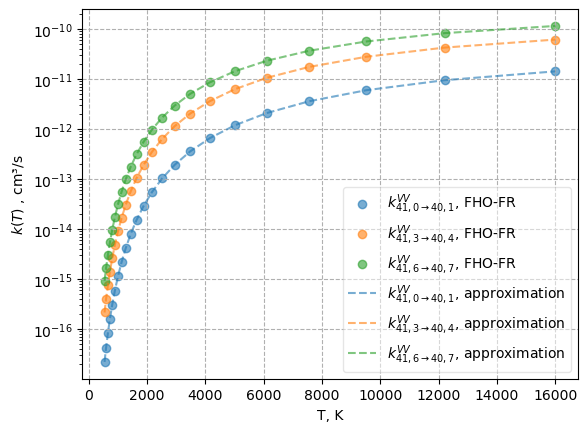

In [15]:
fig, ax = plt.subplots()
x_values = df_k.iloc[:, 0] 

x_values_test = df_test.iloc[:, 0]

for i in range(1, df_k.shape[1], 3):  
    y_values = df_k.iloc[:, i]
    # ax.scatter(x_values, y_values, label=f'41, {i - 1} --> 40, {i}, расчет', color='red', alpha=0.6)
    ax.scatter(x_values, y_values, label=f'$k^{{VV}}_{{41, {i-1} \\rightarrow 40, {i}}}$, FHO-FR', alpha=0.6)
    
# for i in range(1, df_test.shape[1]):  
#     y_values = df_test.iloc[:, i]
#     # ax.scatter(x_values, y_values, label=f'41, {i - 1} --> 40, {i}, расчет', color='red', alpha=0.6)
#     ax.scatter(x_values_test, y_values, label=f'$k^{{VV}}_{{41, {i-1} \\rightarrow 40, {i}}}$, test', alpha=0.6)
    
for i in range(0, pred_values.shape[1], 3):  
    y_values = pred_values.iloc[:, i]
    # ax.plot(x_values, y_values, label=f'41, {i} --> 40, {i+1}, модель', linestyle='--', alpha=0.6)
    ax.plot(x_values, y_values, label=f'$k^{{VV}}_{{41, {i} \\rightarrow 40, {i+1}}}$, approximation', linestyle='--', alpha=0.6)
    
ax.set_yscale('log')
plt.legend(frameon=True, framealpha=0.5, fontsize='medium')
plt.grid(True, linestyle='--')

plt.xlabel('Т, K')
plt.ylabel('$k(T)$ , cm³/s')

fig.savefig('plot_VV_reg.png', dpi=600)
plt.show()


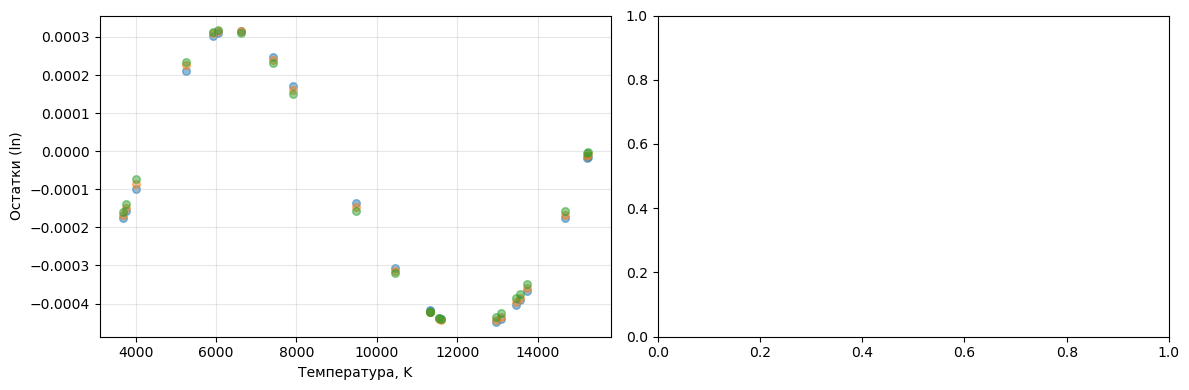

array([-1.75429757e-04, -1.57606581e-04, -9.89108109e-05,  2.11191637e-04,
        3.01692013e-04,  3.09916203e-04,  3.15664996e-04,  2.47965640e-04,
        1.72441563e-04, -1.34973882e-04, -3.06588918e-04, -4.17854239e-04,
       -4.18818002e-04, -4.38648595e-04, -4.41222748e-04, -4.48865593e-04,
       -4.40197145e-04, -4.03465788e-04, -3.91476117e-04, -3.66069083e-04,
       -1.75193053e-04, -1.87906201e-05, -1.60487894e-05, -1.67598542e-04,
       -1.48242367e-04, -8.59219642e-05,  2.25460025e-04,  3.09386008e-04,
        3.16235109e-04,  3.15460233e-04,  2.40404327e-04,  1.61709577e-04,
       -1.47637547e-04, -3.15819446e-04, -4.22415798e-04, -4.23321094e-04,
       -4.41794993e-04, -4.44164534e-04, -4.44495986e-04, -4.35309994e-04,
       -3.97187595e-04, -3.84892518e-04, -3.58975809e-04, -1.67022221e-04,
       -1.13585178e-05, -8.63714141e-06, -1.58388211e-04, -1.37885862e-04,
       -7.30658270e-05,  2.35559664e-04,  3.12499981e-04,  3.18023305e-04,
        3.11378143e-04,  

In [17]:
def test_residuals(df_test, coeffs, model_func):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    all_residuals = []
    mape_values = []
    
    for i in range(1, df_test.shape[1]):
            k_pred = model_func(df_test.iloc[:, 0], *coeffs[i-1]) # логарифм масштаб

            # residuals = np.log(df_test.iloc[:, i] - k_pred)
            residuals = np.log(df_test.iloc[:, i]) - k_pred
            all_residuals.extend(residuals)

            mape = mape_loss(df_test.iloc[:, i], np.exp(k_pred))
            mape_values.append(mape)
  
            ax1.scatter(df_test.iloc[:, 0], residuals, alpha=0.5, s=30)
    
    all_residuals = np.array(all_residuals)

    ax1.set_xlabel('Температура, K')
    ax1.set_ylabel('Остатки (ln)')
    ax1.grid(True, alpha=0.3)
    
    # ax2.hist(all_residuals, bins=15, alpha=0.7, edgecolor='black')
    # ax2.axvline(np.mean(all_residuals), color='red', linestyle='--', 
    #             label=f'Mean: {np.mean(all_residuals):.3f}')
    # ax2.set_xlabel('Остатки')
    # ax2.set_ylabel('Частота')
    # ax2.set_title(f'MAPE среднее: {np.mean(mape_values):.4f}')
    # ax2.legend()
    # ax2.grid(True, alpha=0.3)
    # 
    plt.tight_layout()
    plt.savefig('test_residuals_quick.png', dpi=300)
    plt.show()

    # print(f"\nСтатистика остатков (тестовые данные):")
    # print(f"Всего точек: {len(all_residuals)}")
    # print(f"Среднее остатков: {np.mean(all_residuals):.6f}")
    # print(f"Ст. отклонение: {np.std(all_residuals):.6f}")
    # print(f"MAPE среднее: {np.mean(mape_values):.4f}")
    # print(f"MAPE min/max: {np.min(mape_values):.4f} / {np.max(mape_values):.4f}")
    
    return all_residuals


test_residuals(df_test, coeffs, k_model_poly)

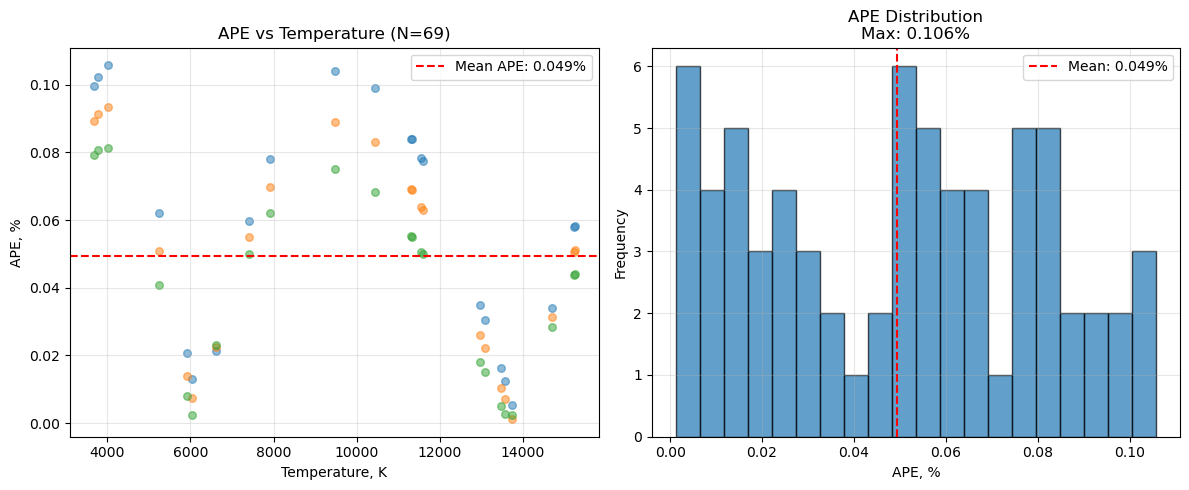

Mean APE: 0.049429%
Std APE: 0.030868%
Max APE: 0.105685%


In [419]:
def plot_APE_test(df_test, coeffs, model_func):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    all_ape = []
    
    for i in range(1, df_test.shape[1]):
        y_exp = df_test.iloc[:, i]
        k_pred = np.exp(model_func(df_test.iloc[:, 0], *coeffs[i-1]))
        
        ape = 100 * np.abs((y_exp - k_pred) / y_exp)
        all_ape.extend(ape)
        
        ax1.scatter(df_test.iloc[:, 0], ape, alpha=0.5, s=30)
    
    all_ape = np.array(all_ape)
    
    ax1.axhline(y=np.mean(all_ape), color='red', linestyle='--', 
                label=f'Mean APE: {np.mean(all_ape):.3f}%')
    ax1.set_xlabel('Temperature, K')
    ax1.set_ylabel('APE, %')
    ax1.set_title(f'APE vs Temperature (N={len(all_ape)})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(all_ape, bins=20, alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(all_ape), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_ape):.3f}%')
    ax2.set_xlabel('APE, %')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'APE Distribution\nMax: {np.max(all_ape):.3f}%')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Mean APE: {np.mean(all_ape):.6f}%")
    print(f"Std APE: {np.std(all_ape):.6f}%")
    print(f"Max APE: {np.max(all_ape):.6f}%")
    
    return all_ape

# Использование
ape_values = plot_APE_test(df_test, coeffs, k_model_poly)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import time

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_log_error

from scipy.optimize import least_squares

In [2]:
def get_coef(coef, T, coef_num):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    #B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    #C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    return A(T**(-1/3))#*np.exp(B(T**(-1/3))) #+ C(T**(-1/3))

def mape_loss(coef, T, k, coef_num, regul_coef):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    #B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    #C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    pred_val = A(T**(-1/3))#*np.exp(B(T**(-1/3))) #+ C(T**(-1/3))
    return np.abs((k - pred_val)/k) + regul_coef*np.sum(np.abs(coef))

def smape_loss(coef, T, k, coef_num, regul_coef):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    #B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    #C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    pred_val = A(T**(-1/3))#*np.exp(B(T**(-1/3))) #+ C(T**(-1/3))
    return np.abs(pred_val - k)/(np.abs(pred_val)+np.abs(k))/2 + regul_coef*np.sum(coef**2)
    
def rmsle_loss(coef, T, k, coef_num, regul_coef):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    pred_val = A(T**(-1/3))*np.exp(B(T**(-1/3))) + C(T**(-1/3))
    return np.log((k+1)/(pred_val+1))**2

1
BEST_POLY_LEN: 6
BEST SCORE: 0.0003184493075934342
BEST COEFS: [-8.30031693e-01  1.19764009e+01 -3.56425396e+02  3.81688929e+03
 -2.07639802e+04  4.56153651e+04]


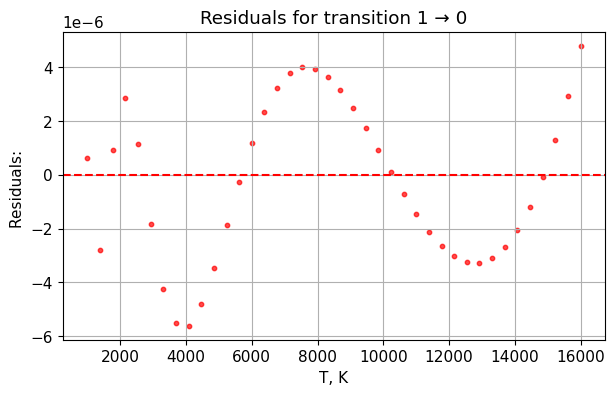

--- 6.03132700920105 seconds ---
2
BEST_POLY_LEN: 6
BEST SCORE: 0.00033518910848670747
BEST COEFS: [-8.26523390e-01  1.17069413e+01 -3.44987536e+02  3.61213241e+03
 -1.91431673e+04  4.07888729e+04]


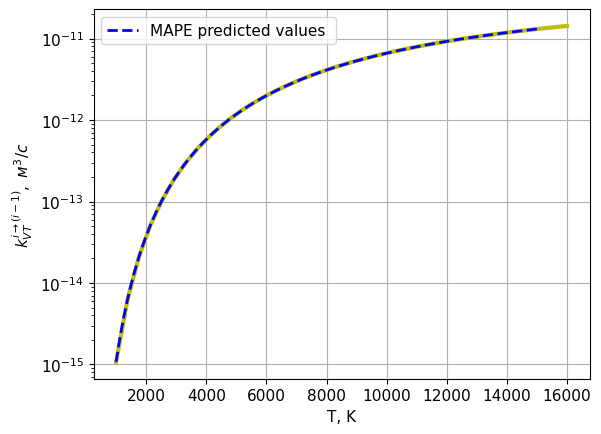

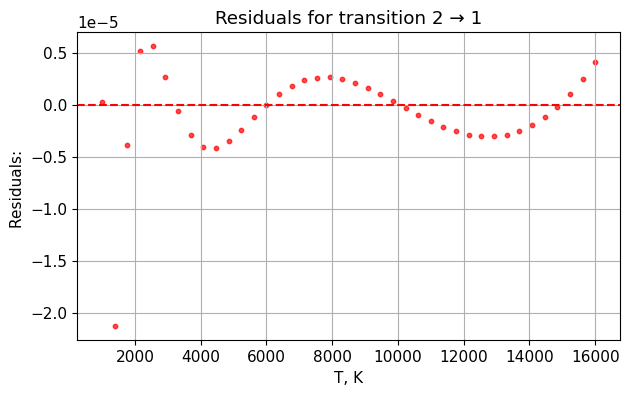

--- 6.550741910934448 seconds ---
3


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

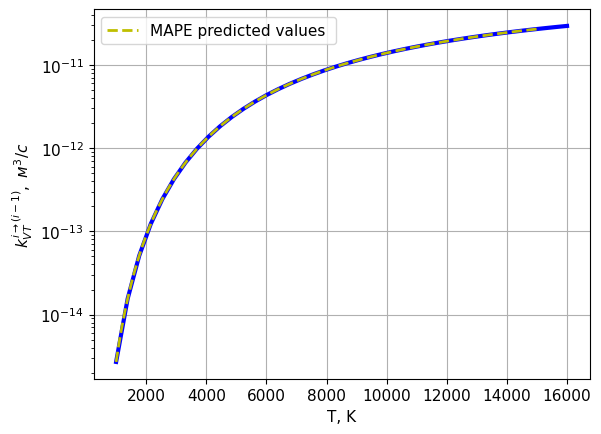

In [24]:
# df = pd.read_csv('kvt_FHO-FR_MM_O2-O2_FULL.txt', sep=' ')
df = pd.read_csv('N2_long.csv')

mape_i_err = []

with open('coefs.txt', 'w') as coef_file:
    max_poly_len = 6
    for k in range(1,36):
        start_time = time.time()
        print(k)
        X = df[df['i']==k]['T']
        y = np.log(df[df['i']==k]['kVT'])
        norm_y = y.abs().max()
        y = y / norm_y

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

        T_1 = X.min()
        T_2 = 15000

        X_for_score1 = df[(df['T'] >= T_1) & (df['T'] <= T_2) & (df['i'] == k)]['T']
        y_for_score = np.log(df[(df['T'] >= T_1) & (df['T'] <= T_2) & (df['i'] == k)]['kVT']) / norm_y

        X_for_figure1 = np.linspace(T_1, T_2, 100000)

        best_score1 = 100

        for i in range(1,max_poly_len+1): 
                #print(i)
                coef_num = i
                regul_coef= 0 #1e1
                x0 = np.ones(coef_num)#*1e-15

                res_mape = least_squares(mape_loss, 
                                         x0, 
                                         method='lm', 
                                         args=(X_train, y_train, coef_num, regul_coef))

                y_mape = np.array([get_coef(res_mape.x, xs, coef_num) for xs in X_for_figure1])
                

                #if np.all(y_mape > 0):
                    #print(f"Coefs: {res_mape.x}")

                MAPE_score1 = np.sum([mape_loss(res_mape.x, *pair, coef_num, 0) for pair in zip(X_for_score1, y_for_score)])/len(X_for_score1)*100
                #print(f'MAPE_score: {MAPE_score1} %')

                if MAPE_score1 < best_score1:
                    best_score1 = MAPE_score1
                    best_coefs1 = res_mape.x
                    poly_len1 = i
                    mape_i_err.append([get_coef(res_mape.x, xs, coef_num) for xs in X])

                    # plt.plot(X, y, label=r'$k_{VT}^{1 \to 0}~FHO-FR$')
                    # plt.plot(X_for_figure1, y_mape, label='MAPE loss')
                    # plt.yscale("logit")
                    # plt.xlabel("T, K")
                    # plt.ylabel("k")
                    # plt.grid()
                    # plt.legend()
                    # plt.show()

        print(f'BEST_POLY_LEN: {poly_len1}')
        print(f'BEST SCORE: {best_score1}')
        print(f'BEST COEFS: {best_coefs1}')
        

        # ОСТАТКИ
   
        X_res = X.values
        y_true_norm = y.values   # log(kVT)/norm_y

        y_pred_norm = np.array([
            get_coef(best_coefs1[:poly_len1], xs, poly_len1)
            for xs in X_res
        ])
        
        residuals = np.exp(y_true_norm * norm_y) - np.exp(y_pred_norm * norm_y)
        residuals_log_norm = y_true_norm - y_pred_norm
        residuals_log = residuals_log * norm_y


        plt.figure(figsize=(7,4))
        # plt.scatter(X_res, residuals, s=10, alpha=0.7, color='green')
        # plt.scatter(X_res, np.log(np.absolute(residuals)), s=10, alpha=0.7, color='green')
        plt.scatter(X_res, residuals_log_norm, s=10, alpha=0.7, color='red')
        # plt.scatter(X_res, residuals_log, s=10, alpha=0.7, color='red')
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel("T, K")
        plt.ylabel(r"Residuals: ")
        plt.title(f"Residuals for transition {k} → {k-1}")
        plt.grid()
        plt.show()



        if len(best_coefs1) < max_poly_len: 
            best_coefs1 = list(best_coefs1) + [0]*(max_poly_len - len(best_coefs1))
        line = [norm_y, *best_coefs1]
        coef_file.write(' '.join(map(str, line)) + '\n')


        X = df[df['i']==k]['T']
        y = df[df['i']==k]['kVT']

        y_mape = np.exp(y_mape*norm_y)
        print("--- %s seconds ---" % (time.time() - start_time))
        
        levels = rf'{k} \to {k-1}'
        label_k = r'$k_{VT}^' + r'{' + levels + r'}' + r'~FHO-FR$'
        
        if k == 1:
            plt_color1 = 'y'
            plt_color2 = 'b--'
        elif k == 5:
            plt_color1 = 'g'
            plt_color2 = 'c--'
        else:
            plt_color1 = 'b'
            plt_color2 = 'y--'


        # print(f'X: {X}')
        # print(f'y: {y}')
        # print(f'X_for_figure1: {X_for_figure1}')
        # print(f'y_mape: {y_mape}')
        
        plt.rcParams.update({'font.size': 11})
        plt.plot(X, y, plt_color1, linewidth=3)
        plt.plot(X_for_figure1, y_mape, plt_color2, label='MAPE predicted values ' , linewidth=2)
        ax = plt.gca()
        #ax.set_xlim([0,10000])
        #ax.set_ylim([1e-17,1e-9])
        plt.yscale("logit")
        plt.xlabel("T, K")
        plt.ylabel(r"$k_{VT}^{i \to (i-1)},~м^3/c$")
        plt.grid()
        plt.legend()
    # plt.savefig(f'O2-O2_{k}->{k-1}_merged.png')
        #plt.show()
    #plt.savefig('res_regression_MM.png', dpi=500, bbox_inches='tight')